In [2]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import os
import pickle
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.models import Model
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [3]:
class ImgProcessing:
    def __init__(self):
        pass
        
    def random_erasing(self, img, sl=0.1, sh=0.2, rl=0.4, p=0.4):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        c = tf.shape(img)[2]
        origin_area = tf.cast(h*w, tf.float32)
        e_size_l = tf.cast(tf.round(tf.sqrt(origin_area * sl * rl)), tf.int32)
        e_size_h = tf.cast(tf.round(tf.sqrt(origin_area * sh / rl)), tf.int32)
        e_height_h = tf.minimum(e_size_h, h)
        e_width_h = tf.minimum(e_size_h, w)
        erase_height = tf.random.uniform(shape=[], minval=e_size_l, maxval=e_height_h, dtype=tf.int32)
        erase_width = tf.random.uniform(shape=[], minval=e_size_l, maxval=e_width_h, dtype=tf.int32)
        erase_area = tf.zeros(shape=[erase_height, erase_width, c])
        erase_area = tf.cast(erase_area, tf.uint8)
        pad_h = h - erase_height
        pad_top = tf.random.uniform(shape=[], minval=0, maxval=pad_h, dtype=tf.int32)
        pad_bottom = pad_h - pad_top
        pad_w = w - erase_width
        pad_left = tf.random.uniform(shape=[], minval=0, maxval=pad_w, dtype=tf.int32)
        pad_right = pad_w - pad_left
        erase_mask = tf.pad([erase_area], [[0,0],[pad_top, pad_bottom], [pad_left, pad_right], [0,0]], constant_values=1)
        erase_mask = tf.squeeze(erase_mask, axis=0)
        erased_img = tf.multiply(tf.cast(img,tf.float32), tf.cast(erase_mask, tf.float32))
        return tf.cond(tf.random.uniform([], 0, 1) > p, lambda: tf.cast(img, img.dtype), lambda:  tf.cast(erased_img, img.dtype))

    
    def CLAHE(self, img):
        gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
        clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(gray)

In [ ]:
class img_dataset:
    def __init__(self, folder_name, labels, encode_labels_dict):  
        self.folder_name = f'../Dataset/kneeKL224/{folder_name}'
        self.labels = labels
        self.encode_labels_dict = encode_labels_dict
        self.filepath = []
        self.df, self.data_shape, self.label_shape = None, None, None
        self.prepro = ImgProcessing()

    
    def load_dataset(self, grayscale=False, n_data=False):
        data, classes = [], []
        for label in self.labels:
            label_folder = os.path.join(self.folder_name, label)
            img_names = os.listdir(label_folder)# type string (e.g. 'abs12.jpg)            
            for img_name in img_names:
                self.filepath.append(img_name)
                img_path = os.path.join(label_folder, img_name)
                img = cv.imread(img_path)
                img = self.prepro.CLAHE(img)
                data.append(cv.resize(img,(224,224)))                
                classes.append(self.encode_labels_dict[label])
        self.df = pd.DataFrame({"filepath" : self.filepath, "label": classes})
        data = np.array(data)
        data = np.expand_dims(data, axis=-1) 
        data = np.repeat(data, 3, axis=-1)
        classes = np.array(classes)
        self.data_shape = data.shape
        self.label_shape = classes.shape
        return data, classes  
    
    def __str__(self) -> str:
        return f"Image Shape: {self.data_shape}\nLabel Shape: {self.label_shape}\nClasses: {self.labels}"

In [41]:
train = img_dataset(labels=['0', '1', '2', '3', '4'],
                       encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                       folder_name='train',
                       )
X_train, Y_train = train.load_dataset(grayscale=False)

In [42]:
valid = img_dataset(labels=['0', '1', '2', '3', '4'],
                       encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                       folder_name='val',
                       )
X_valid, Y_valid = valid.load_dataset(grayscale=False)

In [43]:
def show_fig(original_img, new_img):
    fig = plt.figure(figsize=(14,14))
    ax1, ax2 = fig.subplots(1,2)
    ax1.imshow(original_img)
    ax2.imshow(new_img)    
    plt.show()

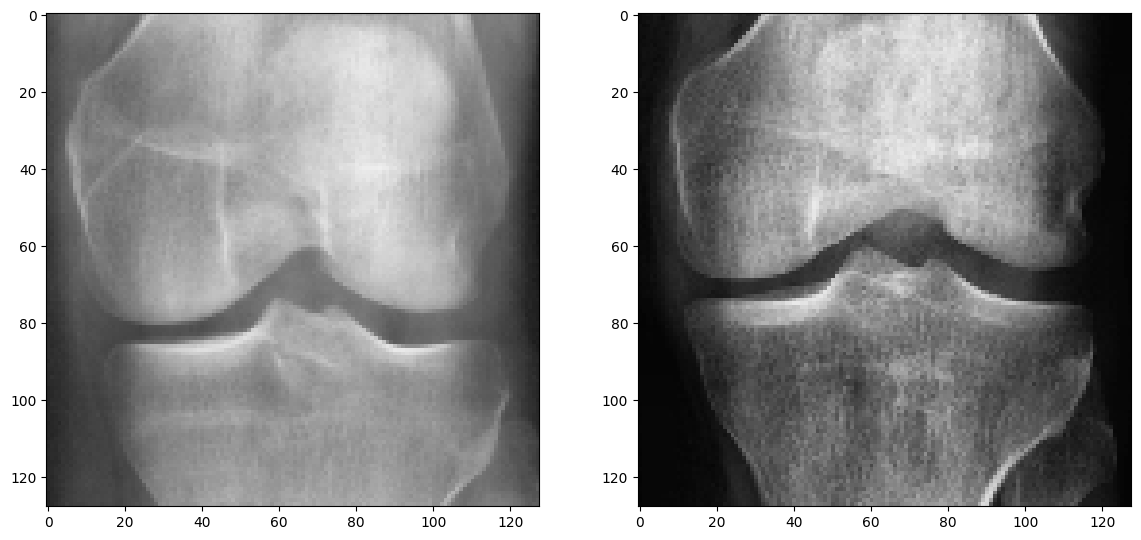

In [44]:
show_fig(X_train[0], X_train[501])

In [45]:
lb = LabelBinarizer()
Y_train = lb.fit_transform(Y_train)
Y_valid = lb.fit_transform(Y_valid)

In [46]:
print('train: ',X_train.shape, Y_train.shape)
print('train: ',X_valid.shape, Y_valid.shape)

train:  (5778, 128, 128, 3) (5778, 5)
train:  (826, 128, 128, 3) (826, 5)


In [ ]:
lr = tf.keras.callbacks.ReduceLROnPlateau(
     monitor="val_accuracy",
     factor=0.1,
     patience=5,
     verbose=2,
     mode="max",
     min_delta=0.0001,
     min_lr=0.000001)

In [ ]:
checkpoint = ModelCheckpoint(filepath='Best_InceptionV3.h5',
                              verbose=2, 
                              save_best_only=True, 
                              monitor = 'val_accuracy')

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=7, 
                                              verbose=2, 
                                              restore_best_weights=True)

callbacks = [checkpoint, early_stopping]

In [ ]:
img_pro = ImgProcessing()
train_aug = ImageDataGenerator(horizontal_flip=True,
                                vertical_flip=False,
                                shear_range=0.2,rotation_range=25,
                                width_shift_range=0.15,
                                height_shift_range=0.15,
                                zoom_range=0.2,
                               brightness_range=[0.8, 1.2],
                                preprocessing_function = img_pro.random_erasing)

val_aug= ImageDataGenerator()

In [ ]:
batch_size=64
train_set = train_aug.flow(X_train,Y_train,
                            batch_size=batch_size, 
                            shuffle= True)
val_set = val_aug.flow(X_valid,Y_valid,
                       batch_size=batch_size, 
                        shuffle= True)

In [ ]:
input_layer = Input(shape=(224, 224, 3))  # RGB input

base_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet', input_tensor=input_layer)

x = base_model.output
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=x)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, None,      │        864 │ input_layer_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, None,      │      9,216 │ activation_94[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, None,      │     18,432 │ activation_95[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, None,      │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, None,      │      5,120 │ max_pooling2d_4[… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, None,      │    138,240 │ activation_97[0]… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, None,      │          0 │ batch_normalizat

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 21,778,597 (83.08 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
H = model.fit(train_set, 
               steps_per_epoch=5778 // batch_size, 
               validation_data=val_set, 
               validation_steps=826 // batch_size, 
               epochs=120, 
               verbose=2, 
               callbacks = callbacks)

C:\Users\jason\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/120


<function matplotlib.pyplot.show(close=None, block=None)>

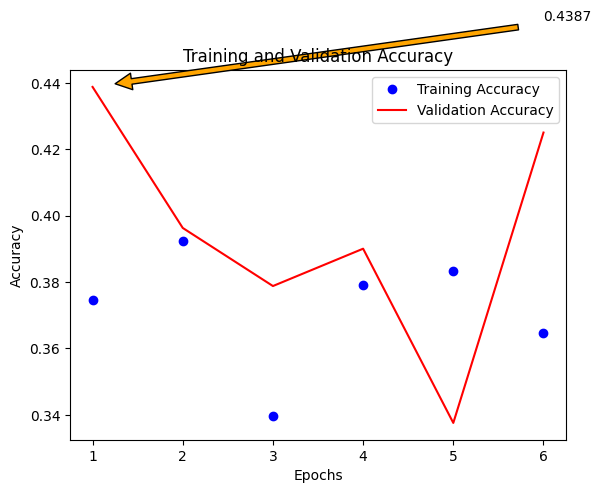

In [37]:
history = model.history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'r', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
y_arrow = max(val_acc)
x_arrow = val_acc.index(y_arrow) + 1
plt.annotate(str(y_arrow)[:6],
              (x_arrow, y_arrow),
              xytext=(x_arrow + 5, y_arrow + .02),
              arrowprops=dict(facecolor='orange', shrink=0.05))
plt.xticks(epochs)
plt.show

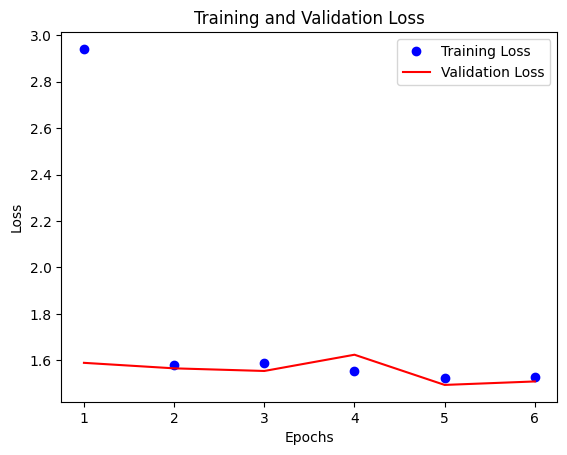

In [38]:
plt.figure()
plt.plot(epochs, loss, 'bo', label = 'Training Loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
plt.show()

In [39]:
test = img_dataset(labels=['0', '1', '2', '3', '4'],
                      encode_labels_dict={'0':0, '1':1, '2':2, '3':3, '4':4},
                      folder_name='test',
                      )
X_test, Y_test = test.load_dataset(grayscale=False)

In [17]:
print(test)
Y_test = lb.fit_transform(Y_test)
print('test: ',X_test.shape, Y_test.shape)
test_aug= ImageDataGenerator()
test_set = test_aug.flow(X_test,Y_test,
                          batch_size=batch_size, 
                          shuffle= False)

Image Shape: (1656, 224, 224, 3)
Label Shape: (1656,)
Classes: ['0', '1', '2', '3', '4']
test:  (1656, 224, 224, 3) (1656, 5)


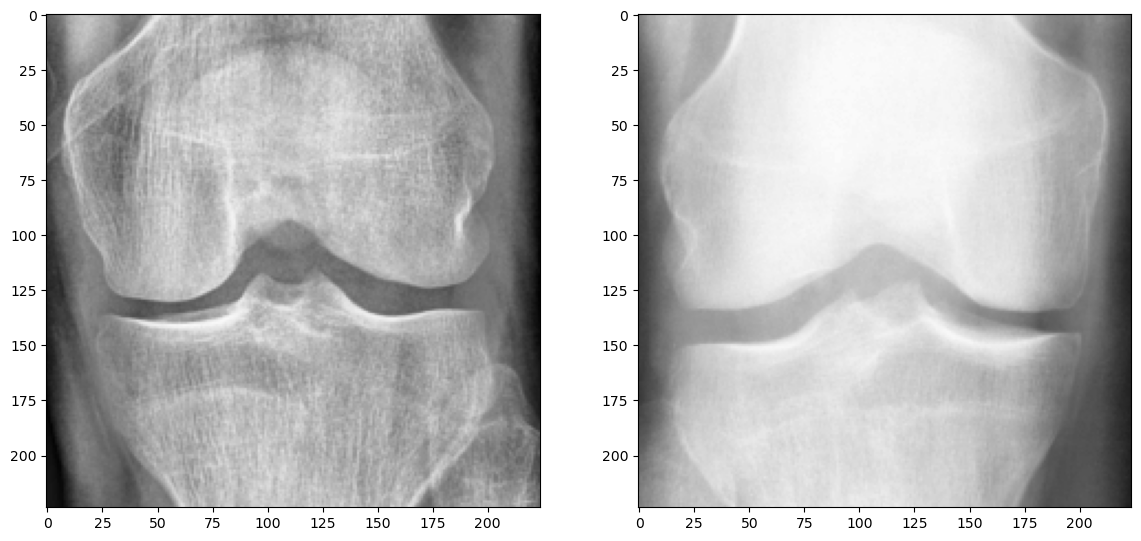

In [16]:
show_fig(X_test[0], X_test[501])

In [ ]:
save_model = tf.keras.models.load_model("../bestmodel/Best_InceptionV3.h5")

In [18]:
save_score= save_model.evaluate(X_test, Y_test)
print(save_score)
print('-------------------------------------')

52/52 [==============================] - 95s 2s/step - loss: 1.1261 - accuracy: 0.6425
[1.1261255741119385, 0.6425120830535889]
-------------------------------------


In [19]:
def encode(array):
    new_array = []
    for i in array:
        index = np.where(i == np.amax(i))[0][0]
        i[index] = int(1)
        for j in range(len(i)):
            if j == index:
                continue
            i[j] = int(0)
        new_array.append(i)
    return new_array

In [20]:
rs_InceptionV3 = encode(save_model.predict(X_test).tolist())

52/52 [==============================] - 96s 2s/step


In [21]:
print('Model accuracy InceptionV3: ', accuracy_score(rs_InceptionV3, Y_test))
print('-------------------------------------')

Model accuracy InceptionV3:  0.642512077294686
-------------------------------------


In [22]:
print('InceptionV3:')
print(classification_report(Y_test, rs_InceptionV3))

InceptionV3:
              precision    recall  f1-score   support

           0       0.67      0.87      0.76       639
           1       0.00      0.00      0.00       296
           2       0.59      0.66      0.62       447
           3       0.66      0.78      0.71       223
           4       0.62      0.78      0.69        51

   micro avg       0.64      0.64      0.64      1656
   macro avg       0.51      0.62      0.56      1656
weighted avg       0.53      0.64      0.58      1656
 samples avg       0.64      0.64      0.64      1656



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.metrics import confusion_matrix
import itertools
y_prediction = np.argmax (rs_InceptionV3, axis = 1)
y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_test, y_prediction)
cm_plot_labels = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

In [22]:
def plot_confusion_matrix(cm, classes, normalize=False, title='InceptionV3 Model Confusion matrix', 
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    
    print(cm)
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Actual Grade')
    plt.xlabel('Predicted Grade')

[[558   0  78   3   0]
 [172   0 108  16   0]
 [ 92   0 293  60   2]
 [  7   0  20 173  23]
 [  0   0   1  10  40]]


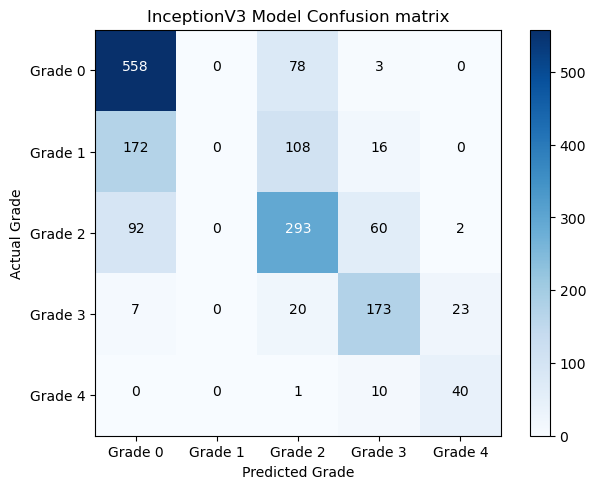

In [23]:
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='InceptionV3 Model Confusion matrix')